# **Analisis Interpretabilitas Model Menggunakan XAI**

# **1. Machine Learning Klasik**

**Analisis XAI Menggunakan LIME, SHAP, dan Koefisien SVM pada Model SVM TF-IDF (Seleksi Fitur ANOVA)**

Loaded dataset, rows = 6760
Loaded tfidf_vectorizer.pkl and anova_selector.joblib
Loaded calibrated SVM from svm_tfidf_calibrated.joblib
svm_tfidf already supports predict_proba

Sample id: 10
Sample text (truncated 400 chars):
kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia narasi lengkap mata uang brics luncur resmi ktt bric ...

=== LIME (local) ===
Prediction (SVM calibrated): Non-Hoax
LIME top features (word -> weight):
 - raymondha            -> -0.1971
 - klaim                -> +0.1041
 - unggah               -> -0.0977
 - ktt                  -> +0.0527
 - bendera              -> -0.0497
 - akun                 -> -0.0470
 - misleading           -> -0.0432
 - lens                 ->

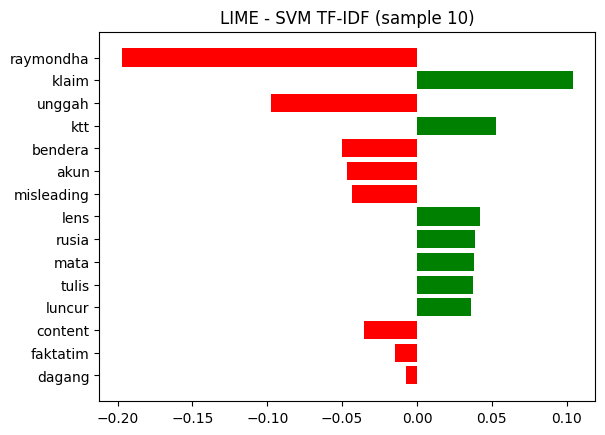


=== SHAP (LinearExplainer on TF-IDF numeric) ===

SHAP local (top 12 features for sample):
 - fattah               -> -0.0847
 - kontaminasi          -> -0.0660
 - kaya                 -> -0.0658
 - serius               -> -0.0536
 - kios                 -> -0.0489
 - raymondha            -> -0.0474
 - unggah               -> -0.0461
 - pengin               -> -0.0402
 - suhartoyo            -> -0.0390
 - jilbab               -> -0.0387
 - hektare              -> -0.0354
 - faktor               -> -0.0325

SHAP global (top 20 features):
 - fattah               -> +0.0852
 - kontaminasi          -> +0.0774
 - serius               -> +0.0746
 - kaya                 -> +0.0680
 - kios                 -> +0.0654
 - raymondha            -> +0.0590
 - unggah               -> +0.0533
 - faktor               -> +0.0517
 - mulyani              -> +0.0487
 - akun                 -> +0.0467
 - suhartoyo            -> +0.0455
 - jilbab               -> +0.0449
 - pengin               -> +0.0405
 

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [ ]:
# ============================================================
# ⭐ XAI FINAL — PERBAHARUIAN: SVM + TF-IDF (ANOVA) — TIDAK ERROR
# ============================================================
# Catatan: jalankan di environment yang sudah memiliki joblib files sebelumnya.
# ============================================================

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
from sklearn.calibration import CalibratedClassifierCV

# ---------------------------
# 1) Load dataset & text
# ---------------------------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values
print("Loaded dataset, rows =", len(texts))

# ---------------------------
# 2) Load TF-IDF vectorizer & ANOVA selector
# ---------------------------
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
anova_selector = joblib.load("anova_selector.joblib")
print("Loaded tfidf_vectorizer.pkl and anova_selector.joblib")

def texts_to_selected_tfidf(list_texts):
    X = tfidf_vectorizer.transform(list_texts)
    return anova_selector.transform(X)

# ---------------------------
# 3) Load SVM models
# ---------------------------
# raw_svm = original LinearSVC saved (has coef_)
raw_svm = joblib.load("svm_tfidf.joblib")   # keep raw for coef / shap linear
# svm_tfidf variable used for predict_proba (may be calibrated)
try:
    svm_tfidf = joblib.load("svm_tfidf_calibrated.joblib")
    print("Loaded calibrated SVM from svm_tfidf_calibrated.joblib")
except Exception:
    svm_tfidf = joblib.load("svm_tfidf.joblib")
    print("Loaded svm_tfidf.joblib (raw) — will calibrate if needed for predict_proba")

# If svm_tfidf doesn't support predict_proba, calibrate it (and save)
if not hasattr(svm_tfidf, "predict_proba"):
    print("svm_tfidf lacks predict_proba — calibrating now (this may take a short while)...")
    X_train_sel, X_test_sel, y_train_sel, y_test_sel = joblib.load("selected_features_anova.joblib")
    svm_cal = CalibratedClassifierCV(svm_tfidf, cv=3, method="sigmoid")
    svm_cal.fit(X_train_sel, y_train_sel)
    svm_tfidf = svm_cal
    joblib.dump(svm_tfidf, "svm_tfidf_calibrated.joblib")
    print("Calibrated and saved as svm_tfidf_calibrated.joblib")
else:
    print("svm_tfidf already supports predict_proba")

# ---------------------------
# 4) Pilih sample
# ---------------------------
sample_id = 10
sample_text = texts[sample_id]
print("\nSample id:", sample_id)
print("Sample text (truncated 400 chars):")
print(sample_text[:400], "...\n")

# ---------------------------
# 5) LIME local explanation
# ---------------------------
print("=== LIME (local) ===")
lime_explainer = LimeTextExplainer(class_names=["Non-Hoax","Hoax"])

def proba_fn_for_lime(texts_list):
    Xsel = texts_to_selected_tfidf(texts_list)
    return svm_tfidf.predict_proba(Xsel)

exp = lime_explainer.explain_instance(sample_text, proba_fn_for_lime, num_features=15, top_labels=1)
pred = svm_tfidf.predict(texts_to_selected_tfidf([sample_text]))[0]
print("Prediction (SVM calibrated):", "Hoax" if pred==1 else "Non-Hoax")
print("LIME top features (word -> weight):")
for w,s in exp.as_list(label=pred):
    print(f" - {w:20s} -> {s:+.4f}")

# Try to show pyplot figure if running in notebook; if not, skip
try:
    fig = exp.as_pyplot_figure(label=pred)
    plt.title("LIME - SVM TF-IDF (sample {})".format(sample_id))
    plt.show()
except Exception:
    pass

# ---------------------------
# 6) SHAP (LinearExplainer on numeric TF-IDF selected)
# ---------------------------
print("\n=== SHAP (LinearExplainer on TF-IDF numeric) ===")
# Load selected TF-IDF split for background
X_train_sel, X_test_sel, y_train_sel, y_test_sel = joblib.load("selected_features_anova.joblib")

# Use raw_svm (LinearSVC) for LinearExplainer to obtain meaningful coefficients-based SHAP
explainer_shap = shap.LinearExplainer(raw_svm, X_train_sel, feature_perturbation="interventional")

# Compute shap values: support both old/new APIs
try:
    shap_vals = explainer_shap.shap_values(X_test_sel)
except Exception:
    shap_exp = explainer_shap(X_test_sel)
    shap_vals = shap_exp.values  # shape: (n_samples, n_features) or list for classes

# Ensure shap_vals is array-like for class of interest.
# For binary classification, shap.LinearExplainer typically returns array (n_samples, n_features) for model output;
# if returns list (per class), pick class 1.
if isinstance(shap_vals, list):
    # shap_vals[class][sample, feature]
    shap_vals_arr = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
else:
    shap_vals_arr = shap_vals

# LOCAL SHAP: sample
sample_shap = shap_vals_arr[sample_id]
# Map feature indices back to token (selected vocab)
feature_mask = anova_selector.get_support(indices=True)
full_vocab = tfidf_vectorizer.get_feature_names_out()
selected_vocab = full_vocab[feature_mask]

print("\nSHAP local (top 12 features for sample):")
idx_local = np.argsort(np.abs(sample_shap))[::-1][:12]
for i in idx_local:
    print(f" - {selected_vocab[i]:20s} -> {sample_shap[i]:+.4f}")

# GLOBAL SHAP: mean abs across test set
print("\nSHAP global (top 20 features):")
mean_abs = np.mean(np.abs(shap_vals_arr), axis=0)
idx_global = np.argsort(mean_abs)[::-1][:20]
for i in idx_global:
    print(f" - {selected_vocab[i]:20s} -> {mean_abs[i]:+.4f}")

# ---------------------------
# 7) Feature importance from raw SVM coef_
# ---------------------------
print("\n=== Model coefficients (raw SVM) ===")
# get coef from raw_svm (LinearSVC)
if hasattr(raw_svm, "coef_"):
    coefs = raw_svm.coef_[0]
else:
    # fallback: try to extract from wrapped estimator
    try:
        coefs = svm_tfidf.base_estimator.coef_[0]
    except Exception:
        coefs = None

if coefs is not None:
    top_pos = np.argsort(coefs)[-15:][::-1]
    top_neg = np.argsort(coefs)[:15]
    print("\nTop positive (mendorong Hoax):")
    for idx in top_pos[:15]:
        print(f" - {selected_vocab[idx]:20s} -> {coefs[idx]:+.4f}")
    print("\nTop negative (mendorong Non-Hoax):")
    for idx in top_neg[:15]:
        print(f" - {selected_vocab[idx]:20s} -> {coefs[idx]:+.4f}")
else:
    print("Tidak dapat mengambil koefisien model (atribut coef_ tidak tersedia).")

print("\n=== XAI selesai ===")


**Analisis XAI Menggunakan LIME dan SHAP pada Model SVM Word2Vec (100-D)**

Loaded dataset, rows = 6760
Loaded balanced_word2vec.joblib
Calibrating SVM W2V (karena tidak ada predict_proba)...
✓ SVM W2V berhasil dikalibrasi!

=== Sample ===
kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia narasi lengkap mata uang brics luncur resmi ktt bric ...

🔥 LIME — Local Explanation (W2V + SVM)
Prediksi: Hoax

🔍 LIME Feature Importance:
 - konten               → +0.0183
 - klaim                → +0.0158
 - sesat                → +0.0152
 - ktt                  → -0.0119
 - misleading           → +0.0117
 - periksa              → +0.0116
 - unggah               → +0.0113
 - narasi               → +0.0099
 - content              → -0.0099
 - uang                 → -0.0084


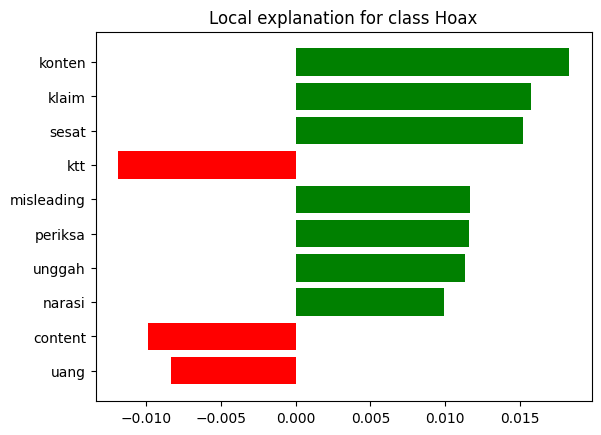


🔥 SHAP — Perbaikan: Kontribusi Per Kata (W2V)

🔍 SHAP Per-Kata (Top 15):
 - isi             → -0.8421
 - isi             → -0.8421
 - mafindo         → -0.8172
 - anggota         → -0.7037
 - anggota         → -0.7037
 - content         → +0.6305
 - content         → +0.6305
 - luncur          → -0.6142
 - luncur          → -0.6142
 - luncur          → -0.6142
 - luncur          → -0.6142
 - dagang          → -0.6137
 - india           → +0.5737
 - ribu            → -0.5439
 - komentar        → +0.5425


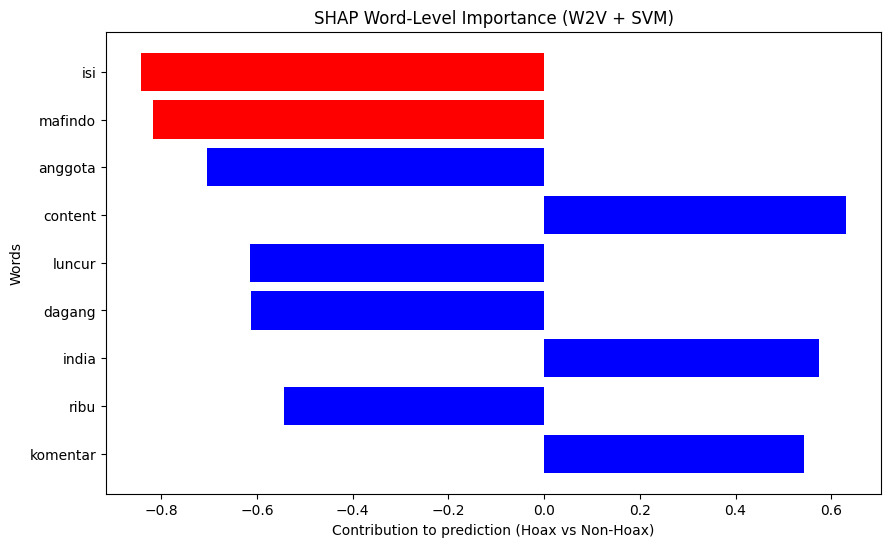

In [ ]:
# ============================================================
# ⭐ XAI — SVM + Word2Vec (100D) — FULL VERSION
# ============================================================

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from lime.lime_text import LimeTextExplainer

# ----------------------------------------
# 1) Load dataset text
# ----------------------------------------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values
print("Loaded dataset, rows =", len(texts))

# ----------------------------------------
# 2) Load Word2Vec features (train/test)
# ----------------------------------------
try:
    X_train_w2v, y_train_w2v, X_test_w2v, y_test_w2v = joblib.load("balanced_word2vec.joblib")
    print("Loaded balanced_word2vec.joblib")
except:
    X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = joblib.load("word2vec_features.joblib")
    print("Loaded word2vec_features.joblib")

# ----------------------------------------
# 3) Load SVM W2V model
# ----------------------------------------
raw_svm_w2v = joblib.load("svm_w2v.joblib")  # raw model → punya coef_
svm_w2v = raw_svm_w2v

# Jika belum punya predict_proba, lakukan kalibrasi
if not hasattr(svm_w2v, "predict_proba"):
    print("Calibrating SVM W2V (karena tidak ada predict_proba)...")

    svm_cal = CalibratedClassifierCV(svm_w2v, cv=3, method="sigmoid")
    svm_cal.fit(X_train_w2v, y_train_w2v)
    svm_w2v = svm_cal
    print("✓ SVM W2V berhasil dikalibrasi!")
else:
    print("✓ SVM W2V sudah memiliki predict_proba")

# ----------------------------------------
# 4) Fungsi untuk vectorize teks → Word2Vec 100D
# ----------------------------------------
from gensim.models import Word2Vec
w2v_model = Word2Vec.load("word2vec_model.model")

def text_to_w2v_vector(text):
    words = text.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vectors, axis=0)

def texts_to_w2v(list_texts):
    return np.array([text_to_w2v_vector(t) for t in list_texts])

# ----------------------------------------
# 5) Pilih sample
# ----------------------------------------
sample_id = 10
sample_text = texts[sample_id]

print("\n=== Sample ===")
print(sample_text[:400], "...")

# ----------------------------------------
# 6) LIME Local Explanation
# ----------------------------------------
print("\n======================================")
print("🔥 LIME — Local Explanation (W2V + SVM)")
print("======================================")

lime_explainer = LimeTextExplainer(class_names=["Non-Hoax", "Hoax"])

def proba_w2v(text_list):
    X = texts_to_w2v(text_list)
    return svm_w2v.predict_proba(X)

exp = lime_explainer.explain_instance(
    sample_text,
    proba_w2v,
    num_features=10,
    top_labels=1
)

pred = svm_w2v.predict(texts_to_w2v([sample_text]))[0]
print("Prediksi:", "Hoax" if pred==1 else "Non-Hoax")

print("\n🔍 LIME Feature Importance:")
for word, score in exp.as_list(label=pred):
    print(f" - {word:20s} → {score:+.4f}")

# tampilkan grafik jika memungkinkan
try:
    fig = exp.as_pyplot_figure(label=pred)
    plt.show()
except:
    pass

print("\n======================================")
print("🔥 SHAP — Perbaikan: Kontribusi Per Kata (W2V)")
print("======================================")

# --- 1) Ambil SHAP local dari kode sebelumnya
local_shap = shap_vals[sample_id]  # shape (100,)

# --- 2) Ambil kata-kata dari teks
words = sample_text.split()
words_in_vocab = [w for w in words if w in w2v_model.wv]

if len(words_in_vocab) == 0:
    print("❌ Tidak ada kata dalam teks yang ada di vocabulary W2V.")
else:
    # --- 3) Hitung kontribusi setiap kata:
    # dot(vektor_kata, shap_vector)
    contributions = []
    for w in words_in_vocab:
        vec = w2v_model.wv[w]                    # (100,)
        score = np.dot(vec, local_shap)          # scalar
        contributions.append((w, score))

    # sort kontribusi
    contributions_sorted = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)

    print("\n🔍 SHAP Per-Kata (Top 15):")
    for w, c in contributions_sorted[:15]:
        print(f" - {w:15s} → {c:+.4f}")

    # --- 4) Visualisasi bar plot SHAP per kata
    words_top = [w for w, _ in contributions_sorted[:15]]
    values_top = [c for _, c in contributions_sorted[:15]]

    plt.figure(figsize=(10, 6))
    colors = ["red" if v > 0 else "blue" for v in values_top]
    plt.barh(words_top[::-1], values_top[::-1], color=colors)
    plt.title("SHAP Word-Level Importance (W2V + SVM)")
    plt.xlabel("Contribution to prediction (Hoax vs Non-Hoax)")
    plt.ylabel("Words")
    plt.show()

# **2. Deep Learning**

**Analisis XAI Menggunakan LIME dan SHAP pada Model MLP TF-IDF**

1) Memuat data & komponen...


 - Loaded selected features (train shape (6226, 2000), test shape (1352, 2000))
 - Loaded TF-IDF vectorizer: tfidf_vectorizer.pkl
 - Loaded chi2 selector from chi2_selector.joblib
 - Selected features count: 2000

2) Memuat model MLP Keras...
 - Model loaded: mlp_tfidf_final.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
 - Quick predict (1 sample) -> (1, 2)

3) LIME — Local Explanation (per kata via mapping TF-IDF feature→kata)

Sample id: 10
Sample (truncated 300 chars): kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics  ...

157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
Prediksi model (MLP): Hoax

LIME — kontribusi token (top features as TF-IDF tokens):
 - faktatim                  -> +0.4981
 - konten    

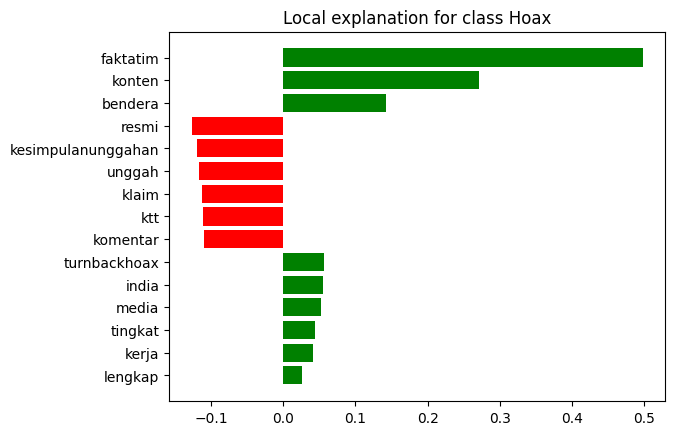

In [ ]:
# ============================================================
# XAI untuk MLP (TF-IDF + SelectKBest Chi2)
# - LIME (local, kata)
# - SHAP (global + local) via KernelExplainer pada fitur TF-IDF terpilih
# ============================================================

import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
from lime.lime_text import LimeTextExplainer
from sklearn.feature_selection import SelectKBest, chi2
from tensorflow.keras.models import load_model

# ----------------------------
# Konfigurasi nama file (ganti jika beda)
# ----------------------------
MODEL_PATH = "mlp_tfidf_final.h5"                 # model Keras yang kamu simpan
SELECTED_FEATURES_FILE = "selected_features_chi2.joblib"  # berisi (X_train_chi2, X_test_chi2, y_train, y_test)
TFIDF_VECTOR_FILE = "tfidf_vectorizer.pkl"       # tfidf vectorizer sebelum seleksi
CHI2_SELECTOR_FILE = "chi2_selector.joblib"      # (opsional) file selector asli, jika ada simpan dan beri nama ini

# ----------------------------
# 1) Load dataset & komponen
# ----------------------------
print("1) Memuat data & komponen...")

# raw texts (untuk mapping fitur -> kata)
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels_all = df["label_num"].values

# load selected features (chi2)
if not os.path.exists(SELECTED_FEATURES_FILE):
    raise FileNotFoundError(f"File {SELECTED_FEATURES_FILE} tidak ditemukan. Pastikan ada di working dir.")

X_train_sel, X_test_sel, y_train_sel, y_test_sel = joblib.load(SELECTED_FEATURES_FILE)
print(f" - Loaded selected features (train shape {X_train_sel.shape}, test shape {X_test_sel.shape})")

# load TF-IDF vectorizer (sebelum selector)
if os.path.exists(TFIDF_VECTOR_FILE):
    tfidf_vec = joblib.load(TFIDF_VECTOR_FILE)
    print(" - Loaded TF-IDF vectorizer:", TFIDF_VECTOR_FILE)
else:
    raise FileNotFoundError(f"TF-IDF vectorizer not found: {TFIDF_VECTOR_FILE}")

# load or reconstruct chi2 selector
if os.path.exists(CHI2_SELECTOR_FILE):
    chi2_selector = joblib.load(CHI2_SELECTOR_FILE)
    print(" - Loaded chi2 selector from", CHI2_SELECTOR_FILE)
else:
    # reconstruct selector using k = number of selected features in X_train_sel
    K = X_train_sel.shape[1]
    print(f" - chi2 selector file not found. Reconstructing SelectKBest(chi2, k={K}) using all texts + labels.")
    # build full TF-IDF on all texts and fit selector
    X_full_tfidf = tfidf_vec.transform(texts)
    chi2_selector = SelectKBest(score_func=chi2, k=K)
    # Note: use labels_all (full dataset) to fit selector — may differ from original training selection
    chi2_selector.fit(X_full_tfidf, labels_all)
    # optional: save reconstructed selector for future runs
    try:
        joblib.dump(chi2_selector, CHI2_SELECTOR_FILE)
        print("   -> Reconstructed selector saved as", CHI2_SELECTOR_FILE)
    except Exception:
        pass

# helper: convert raw text -> selected TF-IDF features (same shape as model input)
def texts_to_selected_tfidf(list_texts):
    Xt = tfidf_vec.transform(list_texts)
    Xsel = chi2_selector.transform(Xt)
    return Xsel

# mapping index of selected feature -> original tfidf token name
full_vocab = tfidf_vec.get_feature_names_out()
selected_idx = chi2_selector.get_support(indices=True)
selected_feature_names = full_vocab[selected_idx]   # length = K

print(f" - Selected features count: {len(selected_feature_names)}")

# ----------------------------
# 2) Load MLP model
# ----------------------------
print("\n2) Memuat model MLP Keras...")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file tidak ditemukan: {MODEL_PATH}")
model = load_model(MODEL_PATH)
print(" - Model loaded:", MODEL_PATH)
# ensure predict_proba wrapper
def model_predict_proba_texts(text_list):
    X = texts_to_selected_tfidf(text_list)
    preds = model.predict(X)
    # preds shape (n,1) with sigmoid
    if preds.ndim == 2 and preds.shape[1] == 1:
        p = preds.ravel()
        return np.vstack([1-p, p]).T
    elif preds.ndim==1:
        p = preds
        return np.vstack([1-p, p]).T
    else:
        return preds  # already probs

# quick sanity predict
print(" - Quick predict (1 sample) ->", model_predict_proba_texts([texts[0]]).shape)

# ----------------------------
# 3) LIME — local explanation (token-level)
# ----------------------------
print("\n3) LIME — Local Explanation (per kata via mapping TF-IDF feature→kata)")
explainer = LimeTextExplainer(class_names=["Non-Hoax","Hoax"])

# select sample
sample_id = 10
sample_text = texts[sample_id]
print("\nSample id:", sample_id)
print("Sample (truncated 300 chars):", sample_text[:300], "...\n")

# LIME needs a function that accepts list[str] -> prob array
def lime_fn(texts_in):
    return model_predict_proba_texts(texts_in)

exp = explainer.explain_instance(sample_text, lime_fn, num_features=15, top_labels=1)

pred_label = model_predict_proba_texts([sample_text]).argmax(axis=1)[0]
print("Prediksi model (MLP):", "Hoax" if pred_label==1 else "Non-Hoax")

print("\nLIME — kontribusi token (top features as TF-IDF tokens):")
# LIME returns tokens (substrings) — we will map LIME tokens to TF-IDF features where possible
for tok, score in exp.as_list(label=pred_label):
    print(f" - {tok:25s} -> {score:+.4f}")

# try show plot (not required)
try:
    fig = exp.as_pyplot_figure(label=pred_label)
    plt.show()
except Exception:
    pass


**Analisis XAI Menggunakan LIME dan SHAP pada Model BiLSTM Word2Vec**

1) Memuat model & tokenizer & embedding...


 - model: bilstm_w2v_final.h5
 - tokenizer: tokenizer_w2v.joblib
 - embedding shape: (30001, 100)

==================== EXPLAIN FULL ====================

--- LIME: Local explanation ---
Text (truncated): kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia na ...

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Model prediction (LIME): Hoax

LIME top token contributions:
 - konten                         -> +0.0822
 - sesat                          -> +0.0777
 - klaim                          -> +0.0730
 - periksa                        -> +0.0644
 - misleading                     -> +0.0630
 - unggah                         -> +0.0439
 - isi                       

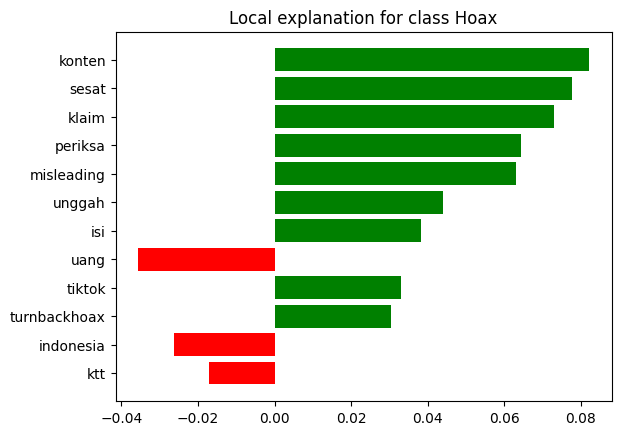


--- SHAP: explanation (DeepExplainer preferred) ---
 - DeepExplainer failed: 'NoneType' object has no attribute 'numpy'
 - Falling back to KernelExplainer (slower).
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
 - KernelExplainer done (nsamples= 100 ).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Model prediction (SHAP): Hoax  | proba: [1.3363361e-04 9.9986637e-01]

Top token contributions (SHAP) — token -> value (signed):
 - kesah           -> +0.0000 (mendorong Hoax)
 - indonesia       -> +0.0000 (mendorong Hoax)
 - klaim           -> -0.0000 (mendorong Non-Hoax)
 - potret          -> -0.0000 (mendorong Non-Hoax)
 - ulang           -> -0.0000 (mendorong Non-Hoax)
 - unggah          -> -0.0000 (mendorong Non-Hoax)
 - com             -> -0.0000 (mendorong Non-Hoax)
 - unggah          -> +0.0000 (mendorong Hoax)
 - arsip           -> -0.0000 (mendorong Non-Hoax)
 - kesah           -> +0.0000 (mendorong Non-Hoax)
 - mata            -> +0.0000 (mendorong Non-Hoax)
 - uang            -> +0.0000 (mendorong Non-Hoax)
 - resmi           -> +0.0000 (mendorong Non-Hoax)
 - brics           -> +0.0000 (mendorong Non-Hoax)
 - isi    

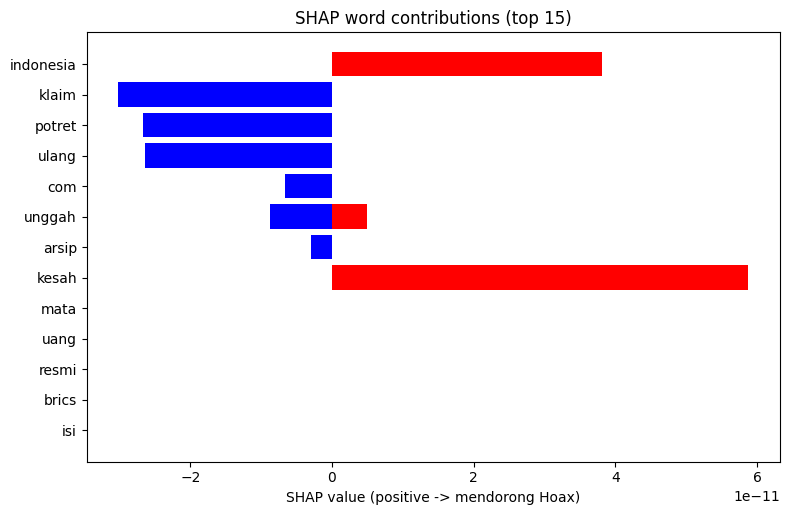


==================== DONE ====================


In [ ]:
# ============================================================
# XAI untuk BiLSTM (Word2Vec) — LIME + SHAP (token-level)
# ============================================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lime.lime_text import LimeTextExplainer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

# -----------------------------
# Config & load artifacts
# -----------------------------
MODEL_PATH = "bilstm_w2v_final.h5"
TOKENIZER_PATH = "tokenizer_w2v.joblib"
EMBED_MATRIX_PATH = "embedding_matrix_w2v.npy"

MAXLEN = 120  # must match training (kode trainingmu memakai 120)

print("1) Memuat model & tokenizer & embedding...")
model = load_model(MODEL_PATH)
tokenizer = joblib.load(TOKENIZER_PATH)
embedding_matrix = np.load(EMBED_MATRIX_PATH)

print(" - model:", MODEL_PATH)
print(" - tokenizer:", TOKENIZER_PATH)
print(" - embedding shape:", embedding_matrix.shape)

# load raw texts for mapping token->word
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values

# helper: convert text list -> padded sequences (same preprocessing as training)
def texts_to_padded_seq(list_texts, maxlen=MAXLEN):
    seqs = tokenizer.texts_to_sequences(list_texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

# helper: model predict_proba wrapper (returns Nx2 probabilities)
def model_predict_proba_from_seqs(X_seq):
    # X_seq should be numpy array shape (n, MAXLEN)
    preds = model.predict(X_seq)
    # sigmoid output shape (n,1) -> produce two-column probabilities
    if preds.ndim == 2 and preds.shape[1] == 1:
        p = preds.ravel()
        p = np.clip(p, 1e-7, 1 - 1e-7)
        return np.vstack([1-p, p]).T
    elif preds.ndim == 1:
        p = preds
        p = np.clip(p, 1e-7, 1 - 1e-7)
        return np.vstack([1-p, p]).T
    else:
        return preds

def model_predict_proba_from_texts(texts_list):
    X = texts_to_padded_seq(texts_list)
    return model_predict_proba_from_seqs(X)

# helper: map sequence (list of token ids) -> token strings (exclude padding 0)
def seq_to_tokens(seq):
    index_word = tokenizer.index_word if hasattr(tokenizer, "index_word") else None
    if index_word is None:
        # fallback: build index_word from tokenizer.word_index
        index_word = {v:k for k,v in tokenizer.word_index.items()}
    tokens = [index_word.get(int(tok), "?") for tok in seq if int(tok) != 0]
    return tokens

# -----------------------------
# LIME — local explanation
# -----------------------------
def explain_lime(text, num_features=12, label_names=["Non-Hoax","Hoax"]):
    print("\n--- LIME: Local explanation ---")
    print("Text (truncated):", text[:350], "...\n")
    explainer = LimeTextExplainer(class_names=label_names)
    # lime expects function list[str] -> 2-col probs
    exp = explainer.explain_instance(text, model_predict_proba_from_texts, num_features=num_features, top_labels=1)
    pred_label = model_predict_proba_from_texts([text]).argmax(axis=1)[0]
    print("Model prediction (LIME):", "Hoax" if pred_label==1 else "Non-Hoax")
    print("\nLIME top token contributions:")
    for tok,score in exp.as_list(label=pred_label):
        print(f" - {tok:30s} -> {score:+.4f}")
    # try show figure
    try:
        fig = exp.as_pyplot_figure(label=pred_label)
        plt.show()
    except Exception:
        pass
    return exp, pred_label

# -----------------------------
# SHAP — DeepExplainer (preferred) or KernelExplainer fallback
# -----------------------------
def explain_shap(text, background_texts=None, nsamples=100):
    """
    Explain a single text.
    background_texts: list of texts used as background (if None, sample from texts)
    Returns: dict with tokens, token_shap_values (signed), pred_label, pred_proba
    """
    print("\n--- SHAP: explanation (DeepExplainer preferred) ---")
    sample_seq = texts_to_padded_seq([text])
    # prepare background sequences
    if background_texts is None:
        # pick 100 random training texts as background (or all if small)
        rng = np.random.default_rng(42)
        n_bg = min(200, len(texts))
        bg_inds = rng.choice(len(texts), size=n_bg, replace=False)
        background_texts = [texts[i] for i in bg_inds]
    X_bg = texts_to_padded_seq(background_texts)

    # Try DeepExplainer (works best for TF/Keras)
    use_deep = True
    shap_values = None
    try:
        # DeepExplainer expects a model and background tensors
        dee = shap.DeepExplainer(model, X_bg[:50])  # limit background for performance
        shap_out = dee.shap_values(sample_seq)  # may produce list (per class) or array
        shap_values = shap_out
        print(" - DeepExplainer succeeded.")
    except Exception as e:
        print(" - DeepExplainer failed:", e)
        print(" - Falling back to KernelExplainer (slower).")
        # KernelExplainer expects a function mapping numeric array -> probs
        ke = shap.KernelExplainer(lambda x: model_predict_proba_from_seqs(x), X_bg[:50])
        shap_out = ke.shap_values(sample_seq, nsamples=nsamples)
        shap_values = shap_out
        use_deep = False
        print(" - KernelExplainer done (nsamples=", nsamples, ").")

    # shap_out may be:
    # - list of arrays per class: shap_out[class][sample, seq_len, embed_dim?] or [sample, seq_len]
    # - or array shape (sample, seq_len, embed_dim) for regression
    # Choose class 1 (Hoax) if list
    if isinstance(shap_values, list):
        # pick class 1 if exists, else take first
        idx_class = 1 if len(shap_values) > 1 else 0
        vals = np.array(shap_values[idx_class])
    else:
        vals = np.array(shap_values)

    # vals shape possibilities:
    # (n_samples, seq_len, embed_dim) OR (n_samples, seq_len)
    vals = np.array(vals)
    if vals.ndim == 3:
        # sum across embedding dimension to obtain per-token contribution
        per_token = vals.sum(axis=2)[0]   # first (and only) sample
    elif vals.ndim == 2:
        per_token = vals[0]
    else:
        raise RuntimeError("Unhandled shap values shape: " + str(vals.shape))

    # Map sequence tokens to token strings (exclude padded zeros)
    seq = sample_seq[0]
    tokens = []
    token_shap = []
    for t, s in zip(seq, per_token):
        if int(t) == 0:
            # padding: skip
            continue
        tokens.append(tokenizer.index_word.get(int(t), "?"))
        token_shap.append(float(s))

    # pair and sort by absolute contribution
    pairs = list(zip(tokens, token_shap))
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)

    pred_proba = model_predict_proba_from_texts([text])[0]
    pred_label = int(np.argmax(pred_proba))

    print("Model prediction (SHAP):", "Hoax" if pred_label==1 else "Non-Hoax", " | proba:", pred_proba)
    print("\nTop token contributions (SHAP) — token -> value (signed):")
    for tok, val in pairs_sorted[:20]:
        direction = "mendorong Hoax" if val > 0 else "mendorong Non-Hoax"
        print(f" - {tok:15s} -> {val:+.4f} ({direction})")

    # plot top 15
    topN = min(15, len(pairs_sorted))
    top_tokens = [p[0] for p in pairs_sorted[:topN]][::-1]
    top_vals   = [p[1] for p in pairs_sorted[:topN]][::-1]
    colors = ["red" if v>0 else "blue" for v in top_vals]
    plt.figure(figsize=(8, max(3, topN*0.35)))
    plt.barh(top_tokens, top_vals, color=colors)
    plt.title("SHAP word contributions (top {})".format(topN))
    plt.xlabel("SHAP value (positive -> mendorong Hoax)")
    plt.tight_layout()
    plt.show()

    return {
        "tokens": tokens,
        "token_shap": token_shap,
        "pairs_sorted": pairs_sorted,
        "pred_label": pred_label,
        "pred_proba": pred_proba,
        "used_deep": use_deep
    }

# -----------------------------
# Convenience: explain both
# -----------------------------
def explain_full(text, background_texts=None, nsamples=100):
    print("\n==================== EXPLAIN FULL ====================")
    exp_lime, pred_lime = explain_lime(text)
    res_shap = explain_shap(text, background_texts=background_texts, nsamples=nsamples)
    print("\n==================== DONE ====================")
    return {"lime": exp_lime, "lime_pred": pred_lime, "shap": res_shap}

# -----------------------------
# USAGE: contoh
# -----------------------------
sample_id = 10
sample_text = texts[sample_id]

# Jalankan LIME + SHAP untuk sample ini:
res = explain_full(sample_text, background_texts=texts[:300], nsamples=100)

# Kalau mau menjelaskan teks lain, panggil:
# explain_full("teks baru di sini...", background_texts=texts[:300], nsamples=100)


# **3. Transfer Learning**

**Analisis XAI Menggunakan LIME dan SHAP pada Model IndoBERT (Transformers)**

Device: cuda
Loading tokenizer & model from ./indobert_hoax
Smoke test predict_proba on a dummy text:
[[9.9997044e-01 2.9510449e-05]]
SAMPLE (truncated): kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia narasi lengkap mata uang brics luncur resmi ktt bric ...


===== LIME explanation =====
Model prediction: Hoax

LIME top token contributions:
 - konten                    -> +0.1390
 - sesat                     -> +0.1055
 - akun                      -> +0.0716
 - narasi                    -> +0.0623
 - content                   -> +0.0419
 - klaim                     -> +0.0354
 - isi                       -> +0.0325
 - kesimpulanunggahan        -> +0.0312
 - membagikanvideo           -> +0.0

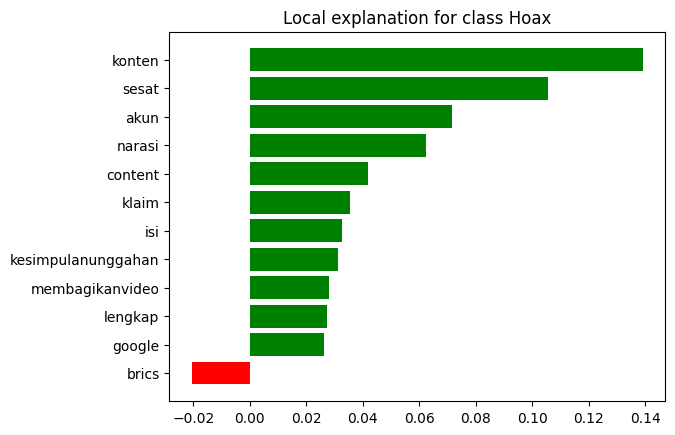


===== SHAP explanation =====
Model prediction (SHAP): Hoax | proba: [2.8378223e-05 9.9997163e-01]

Top token contributions (SHAP) — token -> value (signed):
 - lengkap              -> +0.0202 (mendorong Hoax)
 - indonesia            -> -0.0162 (mendorong Non-Hoax)
 - komentar             -> +0.0153 (mendorong Hoax)
 - ktt                  -> -0.0153 (mendorong Non-Hoax)
 - ungg                 -> +0.0153 (mendorong Hoax)
 - fakta                -> +0.0130 (mendorong Hoax)
 - fakta                -> +0.0129 (mendorong Hoax)
 - gambar               -> +0.0127 (mendorong Hoax)
 - lun                  -> -0.0114 (mendorong Non-Hoax)
 - rusia                -> -0.0106 (mendorong Non-Hoax)
 - back                 -> -0.0103 (mendorong Non-Hoax)
 - selasa               -> -0.0102 (mendorong Non-Hoax)
 - google               -> +0.0100 (mendorong Hoax)
 - resmi                -> -0.0097 (mendorong Non-Hoax)
 - bri                  -> -0.0089 (mendorong Non-Hoax)
 - bri                  -> -0.

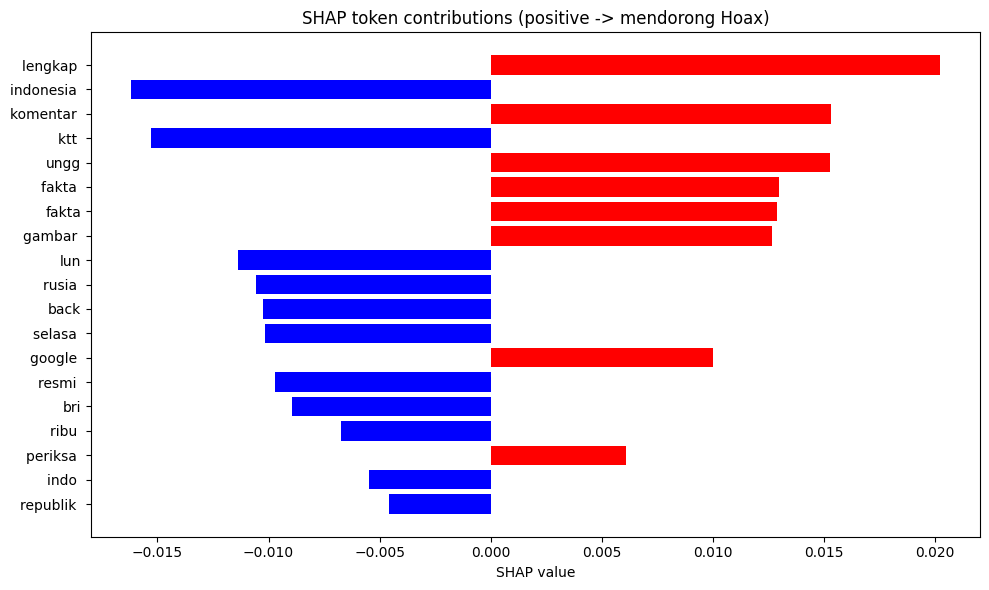

In [ ]:
# ============================================================
# XAI untuk model IndoBERT (transformers) — LIME + SHAP
# ============================================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from lime.lime_text import LimeTextExplainer
import shap
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ------------- CONFIG -------------
MODEL_DIR = "./indobert_hoax"   # folder where trainer saved model & tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ------------- LOAD model & tokenizer -------------
print("Loading tokenizer & model from", MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

# ------------- helper: predict_proba for list[str] -------------
import torch.nn.functional as F

def model_predict_proba(texts, batch_size=16):
    """
    texts: list[str]
    returns: numpy array shape (n, 2) with probabilities for [non-hoax, hoax]
    """
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            outputs = model(**enc)
            logits = outputs.logits  # (batch, num_labels)
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)

# quick smoke test (optional)
print("Smoke test predict_proba on a dummy text:")
print(model_predict_proba(["uji coba model bahasa indonesia"]))

# ------------- Load raw texts (for display) -------------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()

# ------------- LIME explanation (local) -------------
def explain_with_lime(sample_text, class_names=["Non-Hoax","Hoax"], num_features=12):
    print("\n===== LIME explanation =====")
    explainer = LimeTextExplainer(class_names=class_names)
    exp = explainer.explain_instance(sample_text, classifier_fn=model_predict_proba, num_features=num_features, top_labels=1)
    pred_label = int(model_predict_proba([sample_text]).argmax(axis=1)[0])
    print("Model prediction:", "Hoax" if pred_label==1 else "Non-Hoax")
    print("\nLIME top token contributions:")
    for tok,score in exp.as_list(label=pred_label):
        print(f" - {tok:25s} -> {score:+.4f}")
    try:
        fig = exp.as_pyplot_figure(label=pred_label)
        plt.show()
    except Exception:
        pass
    return exp, pred_label

# ------------- SHAP explanation (token-level) -------------
def explain_with_shap(sample_text, background_texts=None, nsamples=200):
    """
    Uses shap.Explainer with shap.maskers.Text(tokenizer).
    background_texts: list[str] for masker background (if None, sample from texts)
    """
    print("\n===== SHAP explanation =====")
    if background_texts is None:
        # choose up to 200 background examples (random subset)
        rng = np.random.default_rng(42)
        n_bg = min(200, len(texts))
        bg_idx = rng.choice(len(texts), size=n_bg, replace=False)
        background_texts = [texts[i] for i in bg_idx]

    # Build a wrapper that accepts a list[str] and returns class probabilities for SHAP
    def predict_fn_for_shap(x):
        # shap may pass numpy array of strings
        xlist = [str(xx) for xx in x]
        return model_predict_proba(xlist)

    # shap.maskers.Text expects a HuggingFace tokenizer object or callable tokenizer
    masker = shap.maskers.Text(tokenizer)

    explainer = shap.Explainer(predict_fn_for_shap, masker, output_names=["Non-Hoax","Hoax"])
    # run explainer on the sample (wrap in list)
    shap_explanation = explainer([sample_text])
    # shap_explanation is a ShapleyExplanation object
    # tokens:
    tokens = shap_explanation.data[0]         # list of token strings
    values = shap_explanation.values         # shape: (n_samples, n_tokens, n_classes) OR (n_samples, n_tokens) depending
    # Determine shape & extract class=1 (Hoax) contributions
    if isinstance(values, list):
        # older API: list per class
        if len(values) > 1:
            vals_for_class = np.array(values[1])[0]   # (n_tokens,)
        else:
            vals_for_class = np.array(values[0])[0]
    else:
        vals = np.array(values)
        if vals.ndim == 3:
            # (n_samples, n_tokens, n_classes) -> take class 1
            vals_for_class = vals[0,:,1]
        elif vals.ndim == 2:
            # (n_samples, n_tokens) -> signed importance (class-specific depends on explainer)
            vals_for_class = vals[0]
        else:
            raise RuntimeError("Unexpected SHAP values shape: " + str(vals.shape))

    # Pair token -> value and sort by absolute importance
    pairs = list(zip(tokens, vals_for_class))
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)

    # Print top tokens
    print("Model prediction (SHAP):", "Hoax" if model_predict_proba([sample_text]).argmax(axis=1)[0]==1 else "Non-Hoax",
          "| proba:", model_predict_proba([sample_text])[0])
    print("\nTop token contributions (SHAP) — token -> value (signed):")
    for tok, val in pairs_sorted[:20]:
        direction = "mendorong Hoax" if val > 0 else "mendorong Non-Hoax"
        print(f" - {tok:20s} -> {val:+.4f} ({direction})")

    # plot top N
    topN = min(20, len(pairs_sorted))
    top_tokens = [p[0] for p in pairs_sorted[:topN]][::-1]
    top_vals   = [p[1] for p in pairs_sorted[:topN]][::-1]
    colors = ["red" if v>0 else "blue" for v in top_vals]
    plt.figure(figsize=(10, max(3, topN*0.3)))
    plt.barh(top_tokens, top_vals, color=colors)
    plt.title("SHAP token contributions (positive -> mendorong Hoax)")
    plt.xlabel("SHAP value")
    plt.tight_layout()
    plt.show()

    return {
        "tokens": tokens,
        "vals_for_class": vals_for_class,
        "pairs_sorted": pairs_sorted,
        "shap_explanation": shap_explanation
    }

# ------------- USAGE EXAMPLE -------------
sample_id = 10
sample_text = texts[sample_id]

print("SAMPLE (truncated):", sample_text[:400], "...\n")

# run LIME
exp_lime, pred_lime = explain_with_lime(sample_text, num_features=12)

# run SHAP (this will use Deep or Partition explainer internally and should map to tokens)
res_shap = explain_with_shap(sample_text, background_texts=texts[:300], nsamples=200)


**Analisis XAI Menggunakan LIME, SHAP, Attention, dan Integrated Gradients pada Model IndoBERT + LoRA**

In [ ]:
# ==============================================
# XAI for IndoBERT + LoRA
# (LIME + SHAP + Attention + Integrated Gradients FIXED)
# ==============================================

import os, torch, numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from peft import PeftModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "indobenchmark/indobert-base-p2"
LORA_DIR = "./indobert_lora"
MAX_LEN = 128

print("Device:", DEVICE)

# -----------------------------
# Load Model + Tokenizer
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

if os.path.isdir(LORA_DIR):
    print("Loading LoRA adapter:", LORA_DIR)
    model = PeftModel.from_pretrained(base_model, LORA_DIR)
else:
    print("LoRA not found → using base model.")
    model = base_model

model.to(DEVICE)
model.eval()

# -----------------------------
# Helper: Predict Probabilities
# -----------------------------
def predict_proba(texts):
    enc = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc).logits
        p = torch.softmax(out, dim=-1).cpu().numpy()
    return p

print("Sanity check:", predict_proba(["uji coba sistem deteksi hoax"]))

# ======================================================
# 1) LIME
# ======================================================
print("\n--- LIME ---")
!pip install -q lime

from lime.lime_text import LimeTextExplainer
explainer_lime = LimeTextExplainer(class_names=["Non-Hoax", "Hoax"])

def lime_predict(x):
    return predict_proba(x)

sample_text = "Ini contoh berita palsu yang menyebut presiden melakukan X tanpa bukti."
lime_exp = explainer_lime.explain_instance(sample_text, lime_predict, num_features=10)
print("LIME:", lime_exp.as_list())

# ======================================================
# 2) SHAP (Pipeline-Compatible)
# ======================================================
print("\n--- SHAP (pipeline) ---")
!pip install -q shap==0.45.1

import shap

clf_pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if DEVICE == "cuda" else -1,
    return_all_scores=True
)

explainer_shap = shap.Explainer(clf_pipe)
shap_values = explainer_shap([sample_text])
print("SHAP computed (ready for shap.plots.text).")

# ======================================================
# 3) Attention Visualization
# ======================================================
print("\n--- Attention ---")

def get_attention(text, layer=-1):
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(DEVICE)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)
    attn = out.attentions[layer][0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    return tokens, attn

tokens, attn_map = get_attention(sample_text, layer=-1)
print("Tokens:", tokens)
print("Attention shape:", attn_map.shape)

plt.figure(figsize=(8,6))
plt.imshow(attn_map[0], cmap="viridis")
plt.title("Attention Head 0")
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=7)
plt.yticks(range(len(tokens)), tokens, fontsize=7)
plt.colorbar()
plt.tight_layout()
plt.show()

# ======================================================
# 4) Integrated Gradients (SAFE GPU VERSION)
# ======================================================
print("\n--- Integrated Gradients FIXED ---")

def integrated_gradients_torch(model, tokenizer, text, target_label=1, baseline_token_id=None, steps=30):
    device = next(model.parameters()).device

    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    embed_layer = model.get_input_embeddings()
    input_embeds = embed_layer(input_ids)   # (1,L,E)

    if baseline_token_id is None:
        baseline = torch.zeros_like(input_embeds)
    else:
        baseline_ids = torch.full_like(input_ids, baseline_token_id)
        baseline = embed_layer(baseline_ids)

    diff = input_embeds - baseline

    total_grads = torch.zeros_like(input_embeds).cpu()

    for k in range(1, steps + 1):
        alpha = k / steps
        emb = (baseline + alpha * diff).detach().requires_grad_(True)

        out = model(inputs_embeds=emb, attention_mask=attention_mask)
        target = out.logits[:, target_label].sum()

        grads = torch.autograd.grad(target, emb)[0]
        total_grads += grads.detach().cpu()

        del emb, out, target, grads
        torch.cuda.empty_cache()

    avg_grads = total_grads / steps
    attributions = (avg_grads.squeeze(0).numpy() * diff.squeeze(0).cpu().numpy()).sum(axis=-1)
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().cpu().numpy())

    return tokens, attributions

tokens_ig, attr_ig = integrated_gradients_torch(model, tokenizer, sample_text, target_label=1, steps=20)

print("Top IG tokens:")
for t, a in sorted(zip(tokens_ig, attr_ig), key=lambda x: -abs(x[1]))[:10]:
    print(f"{t:15} {a:.4f}")

plt.figure(figsize=(10,3))
plt.bar(range(len(attr_ig)), attr_ig)
plt.xticks(range(len(attr_ig)), tokens_ig, rotation=90, fontsize=7)
plt.title("Integrated Gradients Attribution (Hoax)")
plt.tight_layout()
plt.show()

# ======================================================
# 5) Final Combined Report
# ======================================================
def explain(text):
    print("\n====================")
    print("TEXT:", text)
    print("====================")

    probs = predict_proba([text])[0]
    print("\nProbabilities:", {"Non-Hoax": float(probs[0]), "Hoax": float(probs[1])})

    print("\n--- LIME ---")
    print(explainer_lime.explain_instance(text, lime_predict).as_list())

    print("\n--- SHAP ready (use shap.plots.text) ---")

    print("\n--- Attention tokens ---")
    toks, _ = get_attention(text)
    print(toks)

    print("\n--- IG top tokens ---")
    toks_ig, attrs = integrated_gradients_torch(model, tokenizer, text, steps=20)
    for t, a in sorted(zip(toks_ig, attrs), key=lambda x: -abs(x[1]))[:10]:
        print(f"{t:15} {a:.4f}")

# Jalankan
explain(sample_text)


Device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading LoRA adapter: ./indobert_lora
Sanity check: [[0.9777759  0.02222417]]

--- LIME ---
LIME: [(np.str_('presiden'), -0.2586793314325919), (np.str_('tanpa'), -0.25033993954876066), (np.str_('bukti'), 0.216572841620905), (np.str_('berita'), 0.1935072315792101), (np.str_('palsu'), 0.18718139305812156), (np.str_('contoh'), 0.11432713243408262), (np.str_('Ini'), -0.11121982199674588), (np.str_('menyebut'), 0.08778374426444419), (np.str_('X'), -0.08565071994481269), (np.str_('yang'), 0.009985222282148053)]

--- SHAP (pipeline) ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.3/544.3 kB 12.3 MB/s eta 0:00:00


Device set to use cuda:0


SHAP computed (ready for shap.plots.text).

--- Attention ---
Tokens: ['[CLS]', 'ini', 'contoh', 'berita', 'palsu', 'yang', 'menyebut', 'presiden', 'melakukan', 'x', 'tanpa', 'bukti', '.', '[SEP]']
Attention shape: (12, 14, 14)

--- Integrated Gradients FIXED ---
Top IG tokens:
presiden        1.8158
palsu           0.9671
bukti           0.5442
x               0.5190
tanpa           0.3857
.               0.3175
contoh          -0.2773
melakukan       0.2159
ini             0.2084
berita          -0.1645

TEXT: Ini contoh berita palsu yang menyebut presiden melakukan X tanpa bukti.

Probabilities: {'Non-Hoax': 0.6543135046958923, 'Hoax': 0.34568649530410767}

--- LIME ---
[(np.str_('tanpa'), -0.25741439643096115), (np.str_('presiden'), -0.24370634949065587), (np.str_('bukti'), 0.223524946640497), (np.str_('berita'), 0.19588563521369798), (np.str_('palsu'), 0.1910578437579652), (np.str_('contoh'), 0.11561967188317504), (np.str_('Ini'), -0.11314538064967108), (np.str_('menyebut'), 0.090

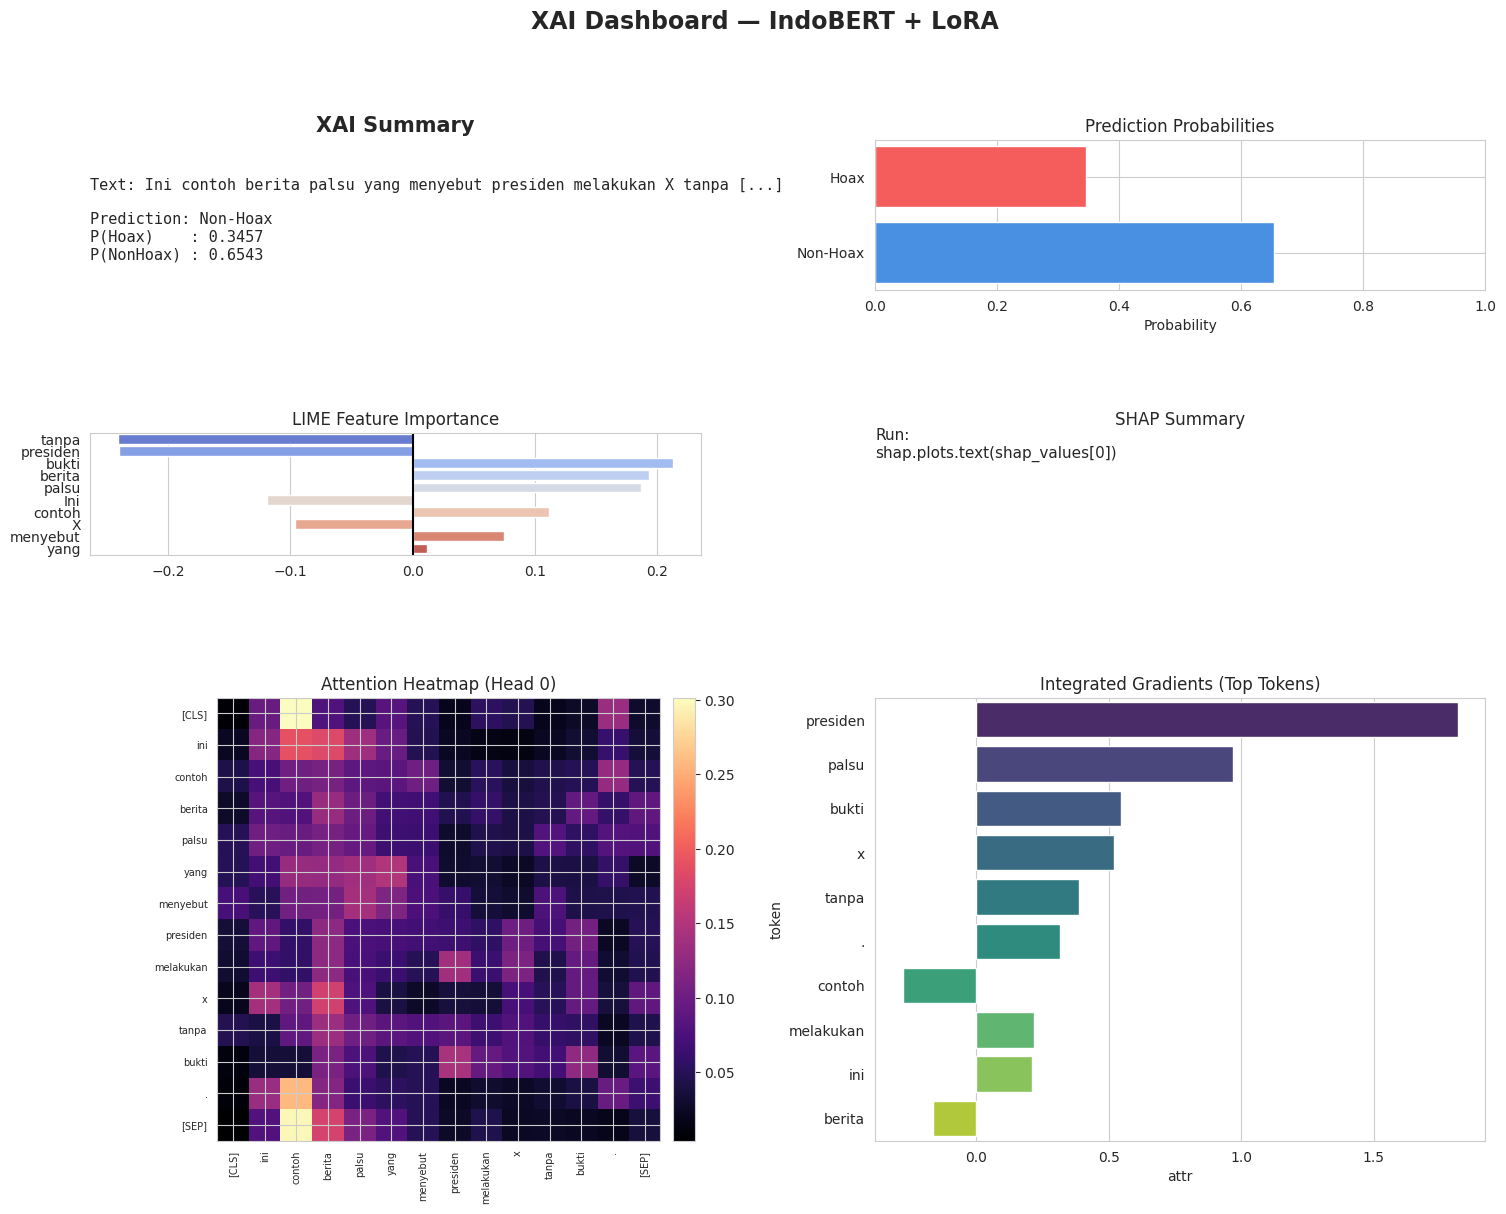


Dashboard generated successfully ✔


In [ ]:
# ==========================================
# XAI DASHBOARD — NO OVERLAP VERSION
# ==========================================

fig = plt.figure(figsize=(18, 13))

# Tinggi tiap baris diperbesar terutama baris pertama
gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1.6, 1.3, 1.6, 1.6],  # <-- baris pertama lebih tinggi
    hspace=1.0,                         # <-- jarak vertikal besar
    wspace=0.8                          # <-- jarak horizontal besar
)

# ---------------------------------------------------
# SUMMARY — kiri atas
# ---------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0:2])
ax0.axis("off")
ax0.set_title("XAI Summary", fontsize=15, fontweight="bold")

# text diringkas & diberi posisi lebih turun
summary_text = (
    f"Text: {shorten(sample_text, width=70)}\n\n"
    f"Prediction: {'Hoax' if pred_label==1 else 'Non-Hoax'}\n"
    f"P(Hoax)    : {probs[1]:.4f}\n"
    f"P(NonHoax) : {probs[0]:.4f}"
)

ax0.text(
    0.0, 0.75,                          # <-- posisi TURUNKAN text agar tidak mepet
    summary_text,
    fontsize=11,
    family="monospace",
    va="top"
)


# ---------------------------------------------------
# PROBABILITIES — kanan atas (diberi margin jauh)
# ---------------------------------------------------
ax1 = fig.add_subplot(gs[0, 2:])
ax1.barh(
    ["Non-Hoax","Hoax"],
    [probs[0], probs[1]],
    color=["#4A90E2","#F55D5D"]
)
ax1.set_xlim(0,1)
ax1.set_title("Prediction Probabilities")
ax1.set_xlabel("Probability")

# beri margin lebih besar ke kiri
ax1.margins(x=0.25)                    # <-- tambahan ruang jauh dari summary


# ---------------------------------------------------
# LIME — kiri tengah
# ---------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0:2])
if lime_result:
    words = [w for w, s in lime_result]
    scores = [s for w, s in lime_result]
    sns.barplot(x=scores, y=words, ax=ax2, palette="coolwarm")
    ax2.set_title("LIME Feature Importance")
    ax2.axvline(0, color="black")
else:
    ax2.text(0.1, 0.5, "LIME unavailable")
    ax2.axis("off")


# ---------------------------------------------------
# SHAP — kanan tengah
# ---------------------------------------------------
ax3 = fig.add_subplot(gs[1, 2:])
ax3.axis("off")
ax3.set_title("SHAP Summary")

if shap_available:
    ax3.text(0, 0.8, "Run:\nshap.plots.text(shap_values[0])", fontsize=11)
else:
    ax3.text(0, 0.5, "SHAP not available", fontsize=11)


# ---------------------------------------------------
# ATTENTION — kiri bawah (dua baris)
# ---------------------------------------------------
ax4 = fig.add_subplot(gs[2:, 0:2])
im = ax4.imshow(attn_map[0], cmap="magma")
ax4.set_title("Attention Heatmap (Head 0)")
ax4.set_xticks(range(len(tokens)))
ax4.set_yticks(range(len(tokens)))
ax4.set_xticklabels(tokens, rotation=90, fontsize=7)
ax4.set_yticklabels(tokens, fontsize=7)
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.02)


# ---------------------------------------------------
# INTEGRATED GRADIENTS — kanan bawah
# ---------------------------------------------------
ax5 = fig.add_subplot(gs[2:, 2:])
df_ig = pd.DataFrame({"token": tokens_ig, "attr": attr_ig})
df_top = df_ig.reindex(df_ig["attr"].abs().sort_values(ascending=False).index).head(10)
sns.barplot(x="attr", y="token", ax=ax5, data=df_top, palette="viridis")
ax5.set_title("Integrated Gradients (Top Tokens)")


plt.suptitle(
    "XAI Dashboard — IndoBERT + LoRA",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

plt.show()

print("\nDashboard generated successfully ✔")
